# 06 — Monthly dynamics bar charts

Notebook de **barras mensuales** usando artifacts ya producidos.

Objetivo: ver dinámica mensual de operación, retiros, FX, unknowns, deuda, cash close y scopes FB/PM/Household.

Reglas:
- no recalcula core accounting;
- no suma ARS + USD;
- USD todo cero/s/d puede ignorarse visualmente;
- `monthly_cash_close` solo es caja auditable si viene frontend-safe/validated;
- `box_balance_*` es diagnóstico;
- FX es treasury/liquidez, no renta/funding/OPEX.


In [1]:

from pathlib import Path
import sys, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 220)
pd.set_option("display.width", 260)

cwd = Path.cwd().resolve()
repo_root = None
for p in [cwd, *cwd.parents]:
    if (p / "Makefile").exists() and (p / "accounting").is_dir():
        repo_root = p
        break
if repo_root is None:
    raise FileNotFoundError("Could not find repo root. Run inside accounting-backend.")

reports_dir = repo_root / "accounting" / "notebooks" / "accounting_reports"
if str(reports_dir) not in sys.path:
    sys.path.insert(0, str(reports_dir))

from _shared import *

repo_root = find_repo_root(repo_root)
pack_dir = professional_pack_dir(repo_root)
fig_dir = pack_dir / "figures" / "monthly_dynamics"
fig_dir.mkdir(parents=True, exist_ok=True)

print("repo_root:", repo_root)
print("pack_dir:", pack_dir)
print("fig_dir:", fig_dir)


repo_root: /home/matias/repos/accounting-backend
pack_dir: /home/matias/repos/accounting-backend/out/professional_pack/latest
fig_dir: /home/matias/repos/accounting-backend/out/professional_pack/latest/figures/monthly_dynamics


In [2]:

# Minimal monthly source registry.
SOURCES = {
    "monthly_operating_statement": [
        "out/run/accounting/latest/monthly_operating_statement.csv",
        "public/accounting/latest/canonical_dashboard/monthly_operating_statement.csv",
    ],
    "monthly_flow_semantic_split": [
        "out/run/accounting/latest/monthly_flow_semantic_split.csv",
        "public/accounting/latest/canonical_dashboard/monthly_flow_semantic_split.csv",
    ],
    "monthly_cash_close": [
        "out/run/accounting/latest/monthly_cash_close.csv",
        "public/accounting/latest/canonical_dashboard/monthly_cash_close.csv",
    ],
    "monthly_debt_position": [
        "out/run/accounting/latest/monthly_debt_position.csv",
        "public/accounting/latest/canonical_dashboard/monthly_debt_position.csv",
        "out/debt_resolution/latest/monthly_debt_position.csv",
    ],
    "monthly_debt_activity": [
        "out/run/accounting/latest/monthly_debt_activity.csv",
        "public/accounting/latest/canonical_dashboard/monthly_debt_activity.csv",
        "out/debt_resolution/latest/monthly_debt_activity.csv",
    ],
    "box_balance_m_diagnostic": [
        "out/run/accounting/latest/box_balance_time_long.freq=M.csv",
        "out/run/accounting/latest/box_balance_time_long.csv",
    ],
}

def first_path(rels):
    for rel in rels:
        p = repo_root / rel
        if p.exists():
            return p
    return None

def read_source(key):
    p = first_path(SOURCES[key])
    if p is None:
        return pd.DataFrame(), None
    df = pd.read_csv(p)
    df.columns = [str(c).strip() for c in df.columns]
    return df, p

def col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def monthify(s):
    s = pd.Series(s).astype(str).str.strip()
    out = s.str.extract(r"(\d{4}-\d{2})", expand=False)
    dt = pd.to_datetime(s, errors="coerce")
    out = out.fillna(dt.dt.to_period("M").astype(str))
    return out

def inv():
    rows = []
    for k, rels in SOURCES.items():
        p = first_path(rels)
        if p is None:
            rows.append({"key": k, "exists": False, "path": "", "rows": 0, "columns": ""})
        else:
            d = pd.read_csv(p, nrows=5)
            rows.append({"key": k, "exists": True, "path": str(p.relative_to(repo_root)), "rows": sum(1 for _ in open(p, "rb"))-1, "columns": ", ".join(map(str, d.columns))})
    return pd.DataFrame(rows)

def norm_op(df):
    if df.empty: return pd.DataFrame()
    p = col(df, ["period","month","TimePeriod","Date","period_end"])
    cur = col(df, ["Currency","currency"])
    line = col(df, ["statement_line","line","metric_id","metric","category"])
    val = col(df, ["amount","value","net_amount"])
    if not (p and line and val):
        print("monthly_operating_statement: cannot normalize", list(df.columns)); return pd.DataFrame()
    return pd.DataFrame({
        "period": monthify(df[p]),
        "Currency": df[cur].astype(str).str.strip() if cur else "N/A",
        "line": df[line].astype(str).str.strip(),
        "amount": pd.to_numeric(df[val], errors="coerce").fillna(0.0),
    })

def norm_flow(df):
    if df.empty: return pd.DataFrame()
    p = col(df, ["period","month","TimePeriod","Date","period_end"])
    cur = col(df, ["Currency","currency"])
    box = col(df, ["Box","box","governance_box","ledger_scope"])
    bucket = col(df, ["semantic_bucket","bucket"])
    sub = col(df, ["semantic_subbucket","subbucket"])
    cash = col(df, ["cash_path","flow_type","Tipo","tipo","channel"])
    payer = col(df, ["payer","Payer","from_actor"])
    receiver = col(df, ["receiver","Receiver","to_actor"])
    actor = col(df, ["actor","Actor","BoxParty","party"])
    counterparty = col(df, ["counterparty","Counterparty"])
    ain = col(df, ["amount_in","in_amount","inflow","value_in","in_amt"])
    aout = col(df, ["amount_out","out_amount","outflow","value_out","out_amt"])
    net = col(df, ["net_amount","signed_amount","net","amount","value"])
    if not p:
        print("monthly_flow_semantic_split: cannot normalize", list(df.columns)); return pd.DataFrame()
    if ain and aout:
        amount_in = pd.to_numeric(df[ain], errors="coerce").fillna(0.0)
        amount_out = pd.to_numeric(df[aout], errors="coerce").fillna(0.0)
        net_amount = amount_in - amount_out
    elif net:
        net_amount = pd.to_numeric(df[net], errors="coerce").fillna(0.0)
        amount_in = net_amount.clip(lower=0.0)
        amount_out = (-net_amount.clip(upper=0.0))
    else:
        print("monthly_flow_semantic_split: no amount cols", list(df.columns)); return pd.DataFrame()
    return pd.DataFrame({
        "period": monthify(df[p]),
        "Currency": df[cur].astype(str).str.strip() if cur else "N/A",
        "Box": df[box].astype(str).str.strip() if box else "N/A",
        "semantic_bucket": df[bucket].astype(str).str.strip() if bucket else "unknown",
        "semantic_subbucket": df[sub].astype(str).str.strip() if sub else "",
        "cash_path": df[cash].astype(str).str.strip() if cash else "",
        "payer": df[payer].astype(str).str.strip() if payer else "",
        "receiver": df[receiver].astype(str).str.strip() if receiver else "",
        "actor": df[actor].astype(str).str.strip() if actor else "",
        "counterparty": df[counterparty].astype(str).str.strip() if counterparty else "",
        "amount_in": amount_in,
        "amount_out": amount_out,
        "net_amount": net_amount,
        "amount_abs": amount_in.abs() + amount_out.abs(),
    })

def norm_debt_pos(df):
    if df.empty: return pd.DataFrame()
    p = col(df, ["period","month","Date","period_end"])
    cur = col(df, ["Currency","currency"])
    debtor = col(df, ["debtor","Debtor"])
    creditor = col(df, ["creditor","Creditor"])
    total = col(df, ["open_total","open_amount","closing_total","value"])
    if not (p and total):
        print("monthly_debt_position: cannot normalize", list(df.columns)); return pd.DataFrame()
    out = pd.DataFrame({
        "period": monthify(df[p]),
        "Currency": df[cur].astype(str).str.strip() if cur else "N/A",
        "debtor": df[debtor].astype(str).str.strip() if debtor else "",
        "creditor": df[creditor].astype(str).str.strip() if creditor else "",
        "open_total": pd.to_numeric(df[total], errors="coerce").fillna(0.0),
    })
    out["pair"] = out["debtor"] + " → " + out["creditor"]
    return out

def norm_debt_act(df):
    if df.empty: return pd.DataFrame()
    p = col(df, ["period","month","Date","period_end"])
    cur = col(df, ["Currency","currency"])
    debtor = col(df, ["debtor","Debtor"])
    creditor = col(df, ["creditor","Creditor"])
    out = pd.DataFrame({
        "period": monthify(df[p]) if p else "",
        "Currency": df[cur].astype(str).str.strip() if cur else "N/A",
        "debtor": df[debtor].astype(str).str.strip() if debtor else "",
        "creditor": df[creditor].astype(str).str.strip() if creditor else "",
    })
    for name, candidates in {
        "new_principal": ["new_principal","new_claims","principal"],
        "interest_accrued": ["interest_accrued","interest"],
        "repayments": ["repayments","repayment"],
        "adjustments": ["adjustments","adjustment"],
        "net_change": ["net_change","change"],
    }.items():
        c = col(df, candidates)
        out[name] = pd.to_numeric(df[c], errors="coerce").fillna(0.0) if c else 0.0
    out["pair"] = out["debtor"] + " → " + out["creditor"]
    return out

def norm_cash(df):
    if df.empty: return pd.DataFrame()
    p = col(df, ["period","month","Date","period_end","as_of_date"])
    cur = col(df, ["Currency","currency"])
    box = col(df, ["Box","box","account_name","account_id"])
    val = col(df, ["close_amount","balance","value","amount"])
    if not (p and val):
        print("monthly_cash_close: cannot normalize", list(df.columns)); return pd.DataFrame()
    out = pd.DataFrame({
        "period": monthify(df[p]),
        "Currency": df[cur].astype(str).str.strip() if cur else "N/A",
        "Box": df[box].astype(str).str.strip() if box else "N/A",
        "close_amount": pd.to_numeric(df[val], errors="coerce").fillna(0.0),
    })
    for c in ["is_frontend_safe","validation_status","cash_suitability","caveat","source_type"]:
        if c in df.columns: out[c] = df[c]
    return out

def export_fig(filename):
    path = fig_dir / filename
    plt.savefig(path, bbox_inches="tight", dpi=140)
    print("saved:", path.relative_to(repo_root))

def plot_group(df, group_col, value_col, title, filename, *, max_groups=8, stacked=False):
    if df is None or df.empty:
        print("No data:", title); return
    x = df.copy()
    x["period"] = x["period"].astype(str)
    x[value_col] = pd.to_numeric(x[value_col], errors="coerce").fillna(0.0)
    x[group_col] = x[group_col].astype(str)
    keep = x.groupby(group_col)[value_col].apply(lambda s: s.abs().sum()).sort_values(ascending=False).head(max_groups).index
    x = x[x[group_col].isin(keep)]
    pivot = x.pivot_table(index="period", columns=group_col, values=value_col, aggfunc="sum", fill_value=0.0).sort_index()
    if pivot.empty:
        print("Empty pivot:", title); return
    plt.figure(figsize=(13,5))
    ax = pivot.plot(kind="bar", stacked=stacked, figsize=(13,5))
    ax.set_title(title); ax.set_xlabel("Mes"); ax.set_ylabel(value_col)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    export_fig(filename)
    plt.show()

def melt_for_plot(df, id_cols, value_cols):
    return df.melt(id_vars=id_cols, value_vars=[c for c in value_cols if c in df.columns], var_name="line", value_name="amount")


## 1. Inventario mensual

In [ ]:
monthly_inventory = inv()
display(monthly_inventory)
export_table(monthly_inventory, repo_root, "monthly_dynamics_sources_inventory.csv")


,key,exists,path,rows,columns
0,monthly_operating_statement,True,out/run/accounting/latest/monthly_operating_st...,1909,"period, period_end, Currency, statement_line, ..."
1,monthly_flow_semantic_split,True,out/run/accounting/latest/monthly_flow_semanti...,787,"period, period_end, Currency, Box, Lugar, acto..."
2,monthly_cash_close,True,out/run/accounting/latest/monthly_cash_close.csv,2208,"period, period_end, as_of_date, Box, party, ac..."
3,monthly_debt_position,True,out/run/accounting/latest/monthly_debt_positio...,489,"period, period_end, as_of_date, debtor, credit..."
4,monthly_debt_activity,True,out/run/accounting/latest/monthly_debt_activit...,1134,"period, period_end, Currency, debtor, creditor..."
5,box_balance_m_diagnostic,True,out/run/accounting/latest/box_balance_time_lon...,156,"TimePeriod, TimePeriod_end, Box, Currency, in_..."


PosixPath('/home/matias/repos/accounting-backend/out/professional_pack/latest/tables/monthly_dynamics_sources_inventory.csv')

## 2. Carga normalizada

In [4]:
raw = {}
paths = {}
for k in SOURCES:
    raw[k], paths[k] = read_source(k)
    print(k, "rows:", len(raw[k]), "path:", "" if paths[k] is None else paths[k].relative_to(repo_root))

op = norm_op(raw["monthly_operating_statement"])
flow = norm_flow(raw["monthly_flow_semantic_split"])
cash = norm_cash(raw["monthly_cash_close"])
debt_pos = norm_debt_pos(raw["monthly_debt_position"])
debt_act = norm_debt_act(raw["monthly_debt_activity"])

display(op.head(20))
display(flow.head(20))
display(debt_pos.head(20))
display(debt_act.head(20))

export_table(op, repo_root, "monthly_dynamics_operating_normalized.csv")
export_table(flow, repo_root, "monthly_dynamics_flow_normalized.csv")
export_table(cash, repo_root, "monthly_dynamics_cash_close_normalized.csv")
export_table(debt_pos, repo_root, "monthly_dynamics_debt_position_normalized.csv")
export_table(debt_act, repo_root, "monthly_dynamics_debt_activity_normalized.csv")


monthly_operating_statement rows: 1909 path: out/run/accounting/latest/monthly_operating_statement.csv
monthly_flow_semantic_split rows: 787 path: out/run/accounting/latest/monthly_flow_semantic_split.csv
monthly_cash_close rows: 2208 path: out/run/accounting/latest/monthly_cash_close.csv
monthly_debt_position rows: 489 path: out/run/accounting/latest/monthly_debt_position.csv
monthly_debt_activity rows: 1134 path: out/run/accounting/latest/monthly_debt_activity.csv
box_balance_m_diagnostic rows: 156 path: out/run/accounting/latest/box_balance_time_long.freq=M.csv


,period,Currency,line,amount
0,2022-01,ARS,operating_revenue,144000.0
1,2022-01,ARS,rent_revenue,144000.0
2,2022-01,ARS,property_opex_true,0.0
3,2022-01,ARS,taxes,0.0
4,2022-01,ARS,services,0.0
5,2022-01,ARS,maintenance,0.0
6,2022-01,ARS,legal,0.0
7,2022-01,ARS,other_property_opex,0.0
8,2022-01,ARS,net_operating,144000.0
9,2022-01,ARS,funding_contributions,0.0


,period,Currency,Box,semantic_bucket,semantic_subbucket,cash_path,payer,receiver,actor,counterparty,amount_in,amount_out,net_amount,amount_abs
0,2022-01,ARS,Family Business,operating_revenue,rent,Cobros:Renta,Inq,FB,Family Business,Inq,60000.0,0.0,60000.0,60000.0
1,2022-01,ARS,Family Business,operating_revenue,rent,Cobros:Renta,Inq,FB,Family Business,Inq,16000.0,0.0,16000.0,16000.0
2,2022-01,ARS,Family Business,operating_revenue,rent,Cobros:Renta,Inq,FB,Family Business,Inq,38000.0,0.0,38000.0,38000.0
3,2022-01,ARS,Family Business,operating_revenue,rent,Cobros:Renta,Inq,FB,Family Business,Inq,30000.0,0.0,30000.0,30000.0
4,2022-01,ARS,Family Business,family_withdrawal_candidate,personal_expense,Transfer:Gasto,FB,Gasto,Family Business,Gasto,0.0,144000.0,-144000.0,144000.0
5,2022-02,ARS,Family Business,operating_revenue,rent,Cobros:Renta,Inq,FB,Family Business,Inq,72000.0,0.0,72000.0,72000.0
6,2022-02,ARS,Family Business,property_opex,maintenance,Pagos:Mantenimiento,FB,Costos,Family Business,Costos,0.0,107500.0,-107500.0,107500.0
7,2022-02,ARS,Family Business,property_opex,taxes,Pagos:Impuestos,FB,Impuestos,Family Business,Impuestos,0.0,19400.0,-19400.0,19400.0
8,2022-02,ARS,Family Business,operating_revenue,rent,Cobros:Renta,Inq,FB,Family Business,Inq,16000.0,0.0,16000.0,16000.0
9,2022-02,ARS,Family Business,operating_revenue,rent,Cobros:Renta,Inq,FB,Family Business,Inq,30000.0,0.0,30000.0,30000.0


,period,Currency,debtor,creditor,open_total,pair
0,2023-05,USD,Alejandro,PM,700.0,Alejandro → PM
1,2023-05,USD,Alejandro,PM,700.0,Alejandro → PM
2,2023-05,USD,Alejandro,PM,700.0,Alejandro → PM
3,2023-05,USD,PM,MI,580.0,PM → MI
4,2023-05,USD,PM,MI,580.0,PM → MI
5,2023-05,USD,PM,MI,580.0,PM → MI
6,2023-05,USD,PM,Primos,120.0,PM → Primos
7,2023-05,USD,PM,Primos,120.0,PM → Primos
8,2023-05,USD,PM,Primos,120.0,PM → Primos
9,2023-06,USD,Alejandro,PM,1396.0,Alejandro → PM


,period,Currency,debtor,creditor,new_principal,interest_accrued,repayments,adjustments,net_change,pair
0,2024-01,USD,Alejandro,MI,0.0,0.0,0.0,0.0,0.0,Alejandro → MI
1,2024-01,USD,Alejandro,MI,0.0,0.0,0.0,0.0,0.0,Alejandro → MI
2,2024-01,USD,Alejandro,MI,0.0,73.0,0.0,0.0,0.0,Alejandro → MI
3,2024-01,USD,Alejandro,MI,0.0,0.0,0.0,0.0,0.0,Alejandro → MI
4,2024-01,USD,Alejandro,MI,0.0,0.0,0.0,0.0,0.0,Alejandro → MI
5,2024-01,USD,Alejandro,MI,0.0,0.0,0.0,0.0,0.0,Alejandro → MI
6,2024-01,USD,Alejandro,MI,0.0,0.0,0.0,0.0,73.0,Alejandro → MI
7,2024-02,USD,Alejandro,MI,0.0,0.0,0.0,0.0,0.0,Alejandro → MI
8,2024-02,USD,Alejandro,MI,0.0,0.0,0.0,0.0,0.0,Alejandro → MI
9,2024-02,USD,Alejandro,MI,0.0,0.0,0.0,0.0,0.0,Alejandro → MI


PosixPath('/home/matias/repos/accounting-backend/out/professional_pack/latest/tables/monthly_dynamics_debt_activity_normalized.csv')

## 3. Operación mensual — ARS

,available_line
0,classification_coverage
1,coverage_after_draws
2,debt_movements
3,dividends
4,family_draws_or_distributions
5,funding_contributions
6,internal_transfers
7,legal
8,maintenance
9,net_operating


,period,Currency,line,amount
0,2022-01,ARS,operating_revenue,144000.0
1,2022-01,ARS,rent_revenue,144000.0
2,2022-01,ARS,property_opex_true,0.0
7,2022-01,ARS,other_property_opex,0.0
8,2022-01,ARS,net_operating,144000.0
23,2022-02,ARS,operating_revenue,118000.0
24,2022-02,ARS,rent_revenue,118000.0
25,2022-02,ARS,property_opex_true,126900.0
30,2022-02,ARS,other_property_opex,0.0
31,2022-02,ARS,net_operating,-8900.0


saved: out/professional_pack/latest/figures/monthly_dynamics/01_operating_monthly_ars.png


<Figure size 1300x500 with 0 Axes>

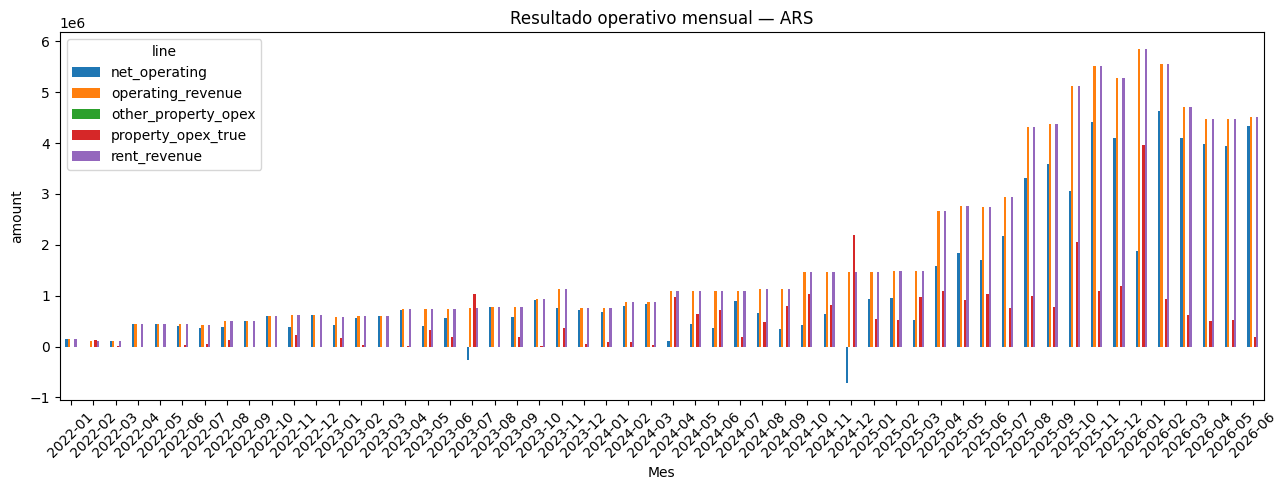

In [5]:
if not op.empty:
    display(pd.DataFrame({"available_line": sorted(op["line"].dropna().astype(str).unique())}))
    op_ars = op[op["Currency"].eq("ARS")].copy()
    mask = op_ars["line"].str.contains("rent|revenue|opex|net_operating|operating", case=False, regex=True, na=False)
    op_sel = op_ars[mask].copy()
    display(op_sel.head(80))
    export_table(op_sel, repo_root, "monthly_dynamics_operating_selected_ars.csv")
    plot_group(op_sel, "line", "amount", "Resultado operativo mensual — ARS", "01_operating_monthly_ars.png", max_groups=8)


## 4. Buckets semánticos mensuales — ARS

,period,semantic_bucket,net_amount,amount_abs
0,2022-01,family_withdrawal_candidate,-144000.0,144000.0
1,2022-01,operating_revenue,144000.0,144000.0
2,2022-02,family_withdrawal_candidate,-8900.0,8900.0
3,2022-02,operating_revenue,118000.0,118000.0
4,2022-02,property_opex,-126900.0,126900.0
5,2022-03,family_withdrawal_candidate,-84200.0,84200.0
6,2022-03,operating_revenue,118000.0,118000.0
7,2022-03,property_opex,-16000.0,16000.0
8,2022-04,family_withdrawal_candidate,-438152.0,438152.0
9,2022-04,operating_revenue,438152.0,438152.0


saved: out/professional_pack/latest/figures/monthly_dynamics/02_semantic_bucket_net_monthly_ars.png


<Figure size 1300x500 with 0 Axes>

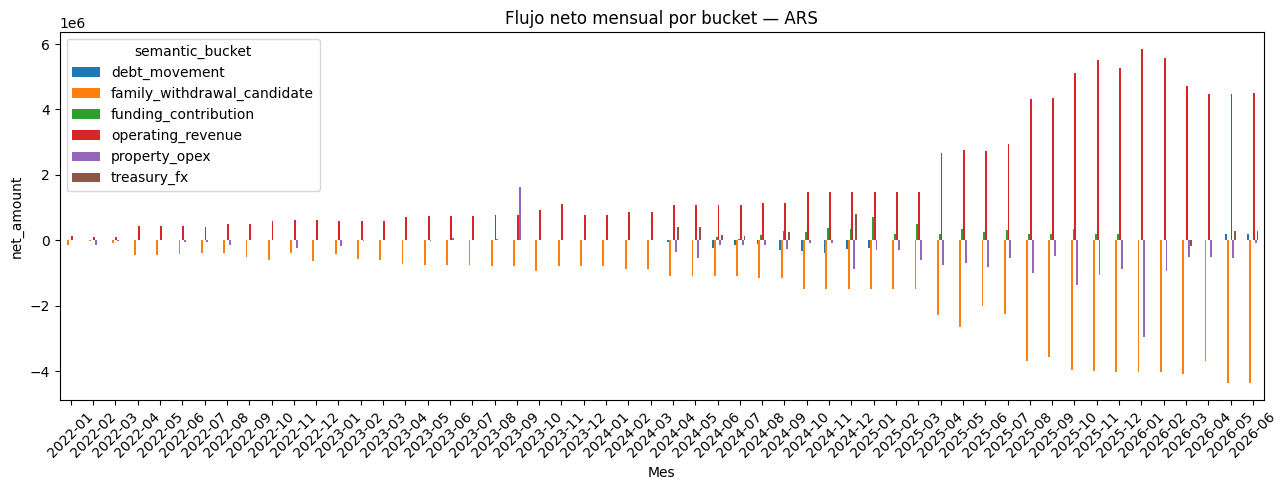

In [6]:
if not flow.empty:
    f_ars = flow[flow["Currency"].eq("ARS")].copy()
    bucket_net = f_ars.groupby(["period","semantic_bucket"], dropna=False).agg(net_amount=("net_amount","sum"), amount_abs=("amount_abs","sum")).reset_index()
    display(bucket_net.head(100))
    export_table(bucket_net, repo_root, "monthly_dynamics_bucket_net_ars.csv")
    plot_group(bucket_net, "semantic_bucket", "net_amount", "Flujo neto mensual por bucket — ARS", "02_semantic_bucket_net_monthly_ars.png", max_groups=10)


## 5. Retiros / gasto familiar-personal por Box

,period,Box,amount_out,net_amount,n_rows
0,2022-01,Family Business,144000.0,-144000.0,1
1,2022-02,Family Business,8900.0,-8900.0,1
2,2022-03,Family Business,84200.0,-84200.0,1
3,2022-04,Family Business,438152.0,-438152.0,1
4,2022-05,Family Business,438152.0,-438152.0,1
5,2022-06,Family Business,405952.0,-405952.0,1
6,2022-07,Family Business,368948.0,-368948.0,1
7,2022-08,Family Business,380266.0,-380266.0,1
8,2022-09,Family Business,505556.0,-505556.0,1
9,2022-10,Family Business,592696.0,-592696.0,1


saved: out/professional_pack/latest/figures/monthly_dynamics/03_draws_by_box_monthly_ars.png


<Figure size 1300x500 with 0 Axes>

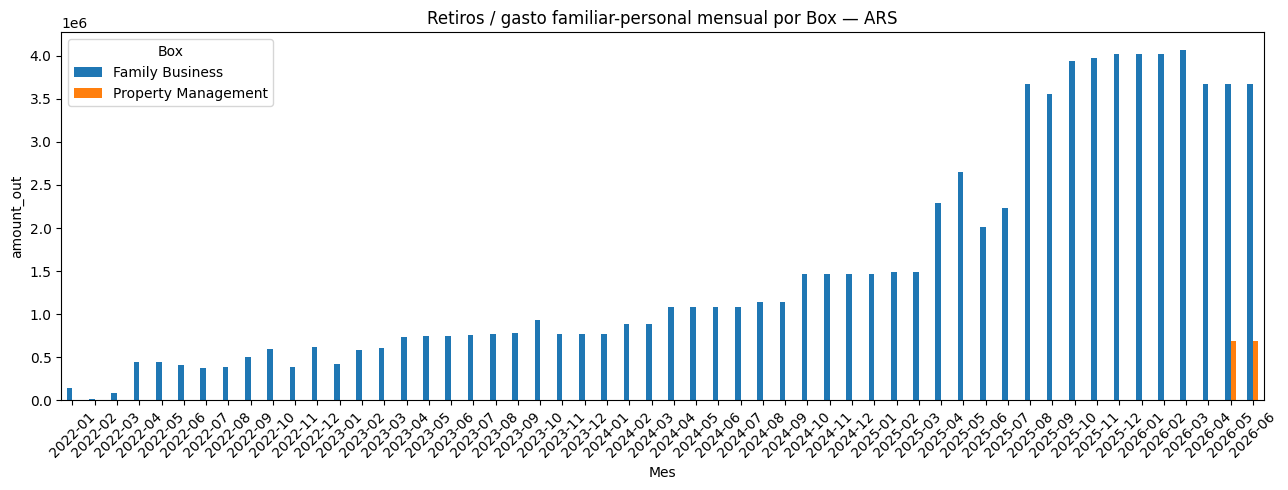

In [7]:
if not flow.empty:
    draws = flow[(flow["Currency"].eq("ARS")) & (flow["semantic_bucket"].eq("family_withdrawal_candidate"))].copy()
    draws_box = draws.groupby(["period","Box"], dropna=False).agg(amount_out=("amount_out","sum"), net_amount=("net_amount","sum"), n_rows=("net_amount","size")).reset_index()
    display(draws_box.head(120))
    export_table(draws_box, repo_root, "monthly_dynamics_draws_by_box_ars.csv")
    plot_group(draws_box, "Box", "amount_out", "Retiros / gasto familiar-personal mensual por Box — ARS", "03_draws_by_box_monthly_ars.png", max_groups=8)


## 6. FB: renta capturada vs retiros

,period,rent_or_revenue_in,withdrawals_out,funding_in,net_flow
0,2022-01,144000.0,144000.0,0.0,0.0
1,2022-02,118000.0,8900.0,0.0,-17800.0
2,2022-03,118000.0,84200.0,0.0,17800.0
3,2022-04,438152.0,438152.0,0.0,0.0
4,2022-05,438152.0,438152.0,0.0,0.0
5,2022-06,438152.0,405952.0,0.0,0.0
6,2022-07,425148.0,368948.0,0.0,0.0
7,2022-08,505556.0,380266.0,0.0,0.0
8,2022-09,505556.0,505556.0,0.0,0.0
9,2022-10,592696.0,592696.0,0.0,0.0


saved: out/professional_pack/latest/figures/monthly_dynamics/04_fb_rent_vs_withdrawals_monthly_ars.png


<Figure size 1300x500 with 0 Axes>

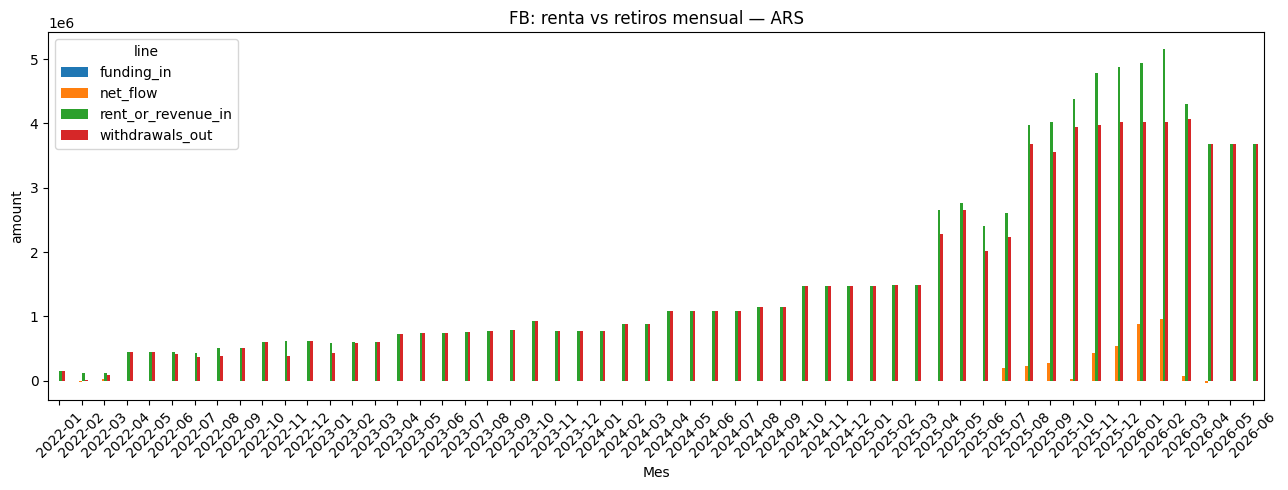

In [8]:
if not flow.empty:
    fb_mask = (
        flow["Box"].str.contains("Family Business|\bFB\b", case=False, regex=True, na=False)
        | flow["payer"].str.contains("Family Business|\bFB\b", case=False, regex=True, na=False)
        | flow["receiver"].str.contains("Family Business|\bFB\b", case=False, regex=True, na=False)
        | flow["actor"].str.contains("Family Business|\bFB\b", case=False, regex=True, na=False)
        | flow["counterparty"].str.contains("Family Business|\bFB\b", case=False, regex=True, na=False)
    )
    fb = flow[flow["Currency"].eq("ARS") & fb_mask].copy()
    periods = sorted(fb["period"].dropna().astype(str).unique())
    fb_bridge = pd.DataFrame({"period": periods})
    def s(mask, col):
        return fb_bridge["period"].map(fb[mask].groupby("period")[col].sum()).fillna(0.0)
    fb_bridge["rent_or_revenue_in"] = s(fb["semantic_bucket"].eq("operating_revenue"), "amount_in")
    fb_bridge["withdrawals_out"] = s(fb["semantic_bucket"].eq("family_withdrawal_candidate"), "amount_out")
    fb_bridge["funding_in"] = s(fb["semantic_bucket"].eq("funding_contribution"), "amount_in")
    fb_bridge["net_flow"] = fb.groupby("period")["net_amount"].sum().reindex(periods).fillna(0.0).values
    display(fb_bridge)
    export_table(fb_bridge, repo_root, "monthly_dynamics_fb_bridge_ars.csv")
    plot_group(melt_for_plot(fb_bridge, ["period"], ["rent_or_revenue_in","withdrawals_out","funding_in","net_flow"]), "line", "amount", "FB: renta vs retiros mensual — ARS", "04_fb_rent_vs_withdrawals_monthly_ars.png", max_groups=6)


## 7. PM stress bridge

,period,revenue_in,property_opex_out,withdrawals_out,funding_in,debt_net,unknown_net,fx_or_treasury_net,net_flow
0,2023-05,0.0,293358.00,0.0,0.0,0.0,0.0,0.0,0.00
1,2023-06,0.0,182532.00,0.0,0.0,0.0,0.0,0.0,80220.00
2,2023-07,0.0,1012730.00,0.0,0.0,0.0,0.0,0.0,0.00
3,2023-08,0.0,0.00,0.0,0.0,0.0,0.0,0.0,60000.00
4,2023-09,0.0,116820.00,0.0,0.0,0.0,0.0,0.0,1626000.00
5,2023-10,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00
6,2023-11,360000.0,230177.00,0.0,0.0,0.0,0.0,0.0,360000.00
7,2023-12,0.0,50700.00,0.0,0.0,0.0,0.0,0.0,0.00
8,2024-01,0.0,22000.00,0.0,0.0,0.0,0.0,0.0,0.00
9,2024-04,0.0,898519.00,0.0,0.0,-53243.0,0.0,400000.0,30.00


saved: out/professional_pack/latest/figures/monthly_dynamics/05_pm_stress_bridge_monthly_ars.png


<Figure size 1300x500 with 0 Axes>

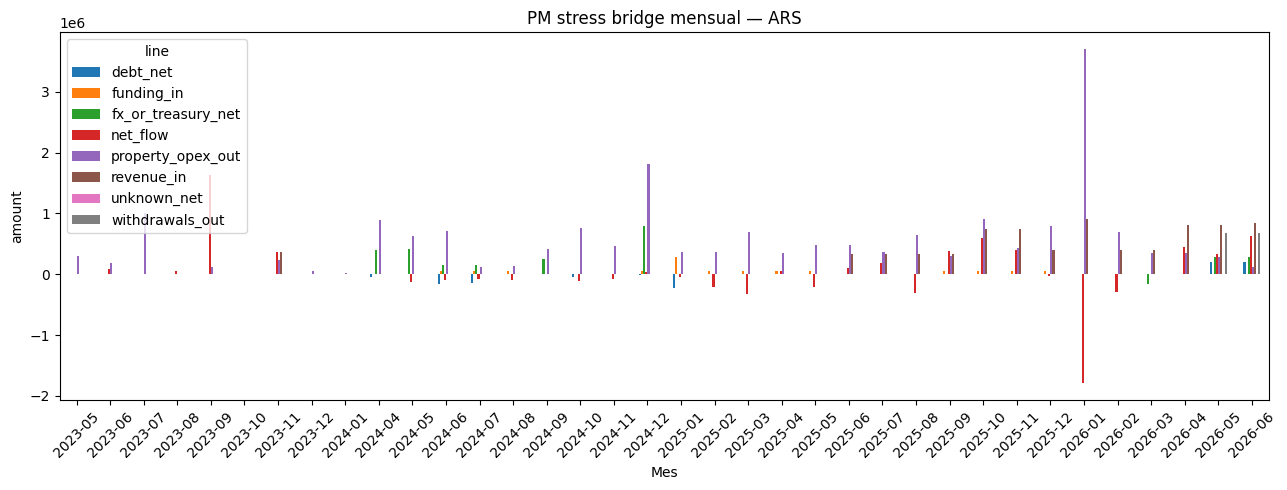

In [9]:
if not flow.empty:
    pm = flow[flow["Currency"].eq("ARS") & flow["Box"].eq("Property Management")].copy()
    periods = sorted(pm["period"].dropna().astype(str).unique())
    pm_bridge = pd.DataFrame({"period": periods})
    b = pm["semantic_bucket"].str.lower()
    sub = pm["semantic_subbucket"].str.lower()
    cashp = pm["cash_path"].str.lower()
    def ps(mask, col):
        return pm_bridge["period"].map(pm[mask].groupby("period")[col].sum()).fillna(0.0)
    pm_bridge["revenue_in"] = ps(b.eq("operating_revenue"), "amount_in")
    pm_bridge["property_opex_out"] = ps(b.eq("property_opex"), "amount_out")
    pm_bridge["withdrawals_out"] = ps(b.eq("family_withdrawal_candidate"), "amount_out")
    pm_bridge["funding_in"] = ps(b.eq("funding_contribution"), "amount_in")
    pm_bridge["debt_net"] = ps(b.str.contains("debt", na=False), "net_amount")
    pm_bridge["unknown_net"] = ps(b.str.contains("unknown|review", na=False) | sub.str.contains("unknown|review", na=False), "net_amount")
    pm_bridge["fx_or_treasury_net"] = ps(b.str.contains("treasury_fx|fx", na=False) | sub.str.contains("fx", na=False) | cashp.str.contains("fx|cambio", na=False), "net_amount")
    pm_bridge["net_flow"] = pm.groupby("period")["net_amount"].sum().reindex(periods).fillna(0.0).values
    display(pm_bridge)
    export_table(pm_bridge, repo_root, "monthly_dynamics_pm_stress_bridge_ars.csv")
    plot_group(melt_for_plot(pm_bridge, ["period"], [c for c in pm_bridge.columns if c != "period"]), "line", "amount", "PM stress bridge mensual — ARS", "05_pm_stress_bridge_monthly_ars.png", max_groups=10)


## 8. Household bridge

,period,funding_in,opex_out,withdrawals_out,debt_net,net_flow
0,2023-01,0.0,2700.00,0.0,0.0,0.00
1,2023-02,0.0,7275.00,0.0,0.0,0.00
2,2023-04,0.0,6500.00,0.0,0.0,0.00
3,2023-05,0.0,41876.00,0.0,0.0,-18838.00
4,2023-06,0.0,3039.00,0.0,0.0,0.00
5,2023-07,0.0,10986.00,0.0,0.0,0.00
6,2023-09,0.0,80584.00,0.0,0.0,0.00
7,2023-10,0.0,17607.00,0.0,0.0,0.00
8,2023-11,0.0,142901.00,0.0,0.0,0.00
9,2024-01,0.0,66286.00,0.0,0.0,0.00


saved: out/professional_pack/latest/figures/monthly_dynamics/06_household_bridge_monthly_ars.png


<Figure size 1300x500 with 0 Axes>

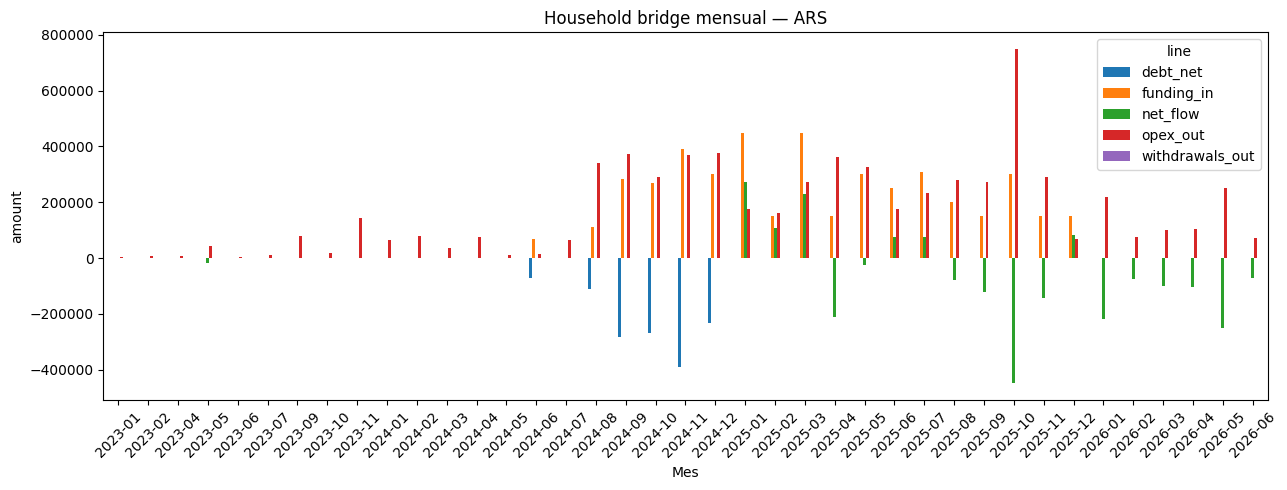

In [10]:
if not flow.empty:
    hh = flow[flow["Currency"].eq("ARS") & flow["Box"].eq("Household")].copy()
    periods = sorted(hh["period"].dropna().astype(str).unique())
    hh_bridge = pd.DataFrame({"period": periods})
    b = hh["semantic_bucket"].str.lower()
    def hs(mask, col):
        return hh_bridge["period"].map(hh[mask].groupby("period")[col].sum()).fillna(0.0)
    hh_bridge["funding_in"] = hs(b.eq("funding_contribution"), "amount_in")
    hh_bridge["opex_out"] = hs(b.eq("property_opex"), "amount_out")
    hh_bridge["withdrawals_out"] = hs(b.eq("family_withdrawal_candidate"), "amount_out")
    hh_bridge["debt_net"] = hs(b.str.contains("debt", na=False), "net_amount")
    hh_bridge["net_flow"] = hh.groupby("period")["net_amount"].sum().reindex(periods).fillna(0.0).values
    display(hh_bridge)
    export_table(hh_bridge, repo_root, "monthly_dynamics_household_bridge_ars.csv")
    plot_group(melt_for_plot(hh_bridge, ["period"], [c for c in hh_bridge.columns if c != "period"]), "line", "amount", "Household bridge mensual — ARS", "06_household_bridge_monthly_ars.png", max_groups=8)


## 9. OPEX por categoría

,period,semantic_subbucket,amount_out,n_rows
0,2022-02,maintenance,107500.00,1
1,2022-02,taxes,19400.00,1
2,2022-03,taxes,16000.00,1
3,2022-06,legal,6800.00,1
4,2022-06,services,2200.00,1
5,2022-06,taxes,23200.00,1
6,2022-07,maintenance,8000.00,1
7,2022-07,services,25000.00,1
8,2022-07,taxes,23200.00,1
9,2022-08,legal,11900.00,1


saved: out/professional_pack/latest/figures/monthly_dynamics/07_opex_by_category_monthly_ars.png


<Figure size 1300x500 with 0 Axes>

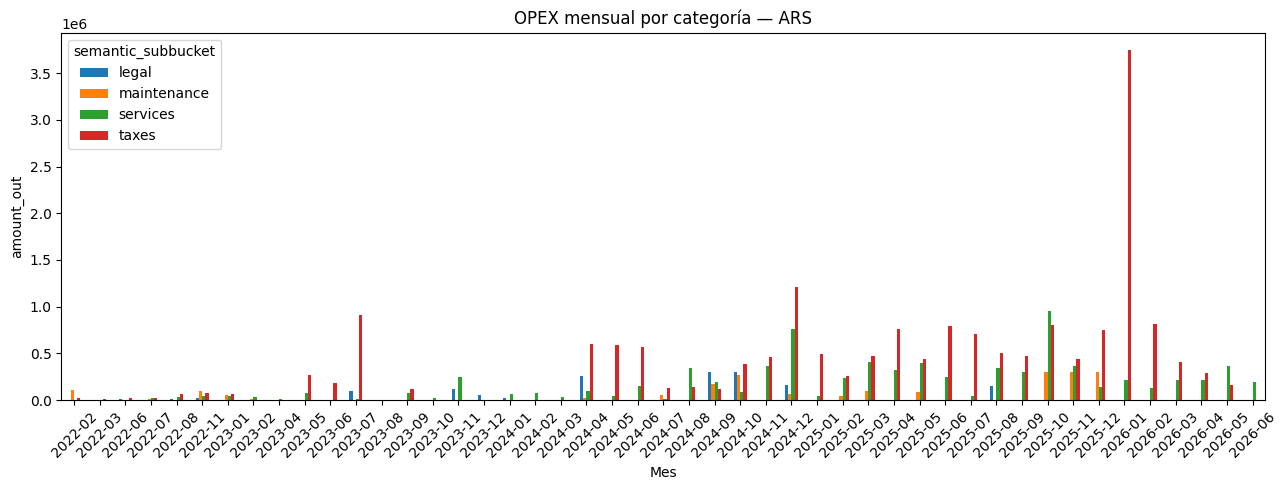

In [11]:
if not flow.empty:
    opex = flow[(flow["Currency"].eq("ARS")) & (flow["semantic_bucket"].eq("property_opex"))].copy()
    opex_type = opex.groupby(["period","semantic_subbucket"], dropna=False).agg(amount_out=("amount_out","sum"), n_rows=("net_amount","size")).reset_index()
    display(opex_type.head(120))
    export_table(opex_type, repo_root, "monthly_dynamics_opex_by_type_ars.csv")
    plot_group(opex_type, "semantic_subbucket", "amount_out", "OPEX mensual por categoría — ARS", "07_opex_by_category_monthly_ars.png", max_groups=8)


## 10. FX monthly audit

,period,Currency,Box,semantic_bucket,semantic_subbucket,cash_path,amount_in,amount_out,net_amount,amount_abs,n_rows
0,2024-04,ARS,Property Management,treasury_fx,fx_conversion_proceeds,Cambio:FX,400000.0,0.0,400000.0,400000.0,1
1,2024-04,USD,Property Management,treasury_fx,fx_conversion_outflow,Cambio:FX,0.0,400.0,-400.0,400.0,1
2,2024-05,ARS,Property Management,treasury_fx,fx_conversion_proceeds,Cambio:FX,410000.0,0.0,410000.0,410000.0,1
3,2024-05,USD,Property Management,treasury_fx,fx_conversion_outflow,Cambio:FX,0.0,400.0,-400.0,400.0,1
4,2024-06,ARS,Property Management,treasury_fx,fx_conversion_proceeds,Cambio:FX,156000.0,0.0,156000.0,156000.0,1
5,2024-06,USD,Property Management,treasury_fx,fx_conversion_outflow,Cambio:FX,0.0,120.0,-120.0,120.0,1
6,2024-07,ARS,Property Management,treasury_fx,fx_conversion_proceeds,Cambio:FX,150000.0,0.0,150000.0,150000.0,1
7,2024-07,USD,Property Management,treasury_fx,fx_conversion_outflow,Cambio:FX,0.0,110.0,-110.0,110.0,1
8,2024-09,ARS,Property Management,treasury_fx,fx_conversion_proceeds,Cambio:FX,248000.0,0.0,248000.0,248000.0,1
9,2024-09,USD,Property Management,treasury_fx,fx_conversion_outflow,Cambio:FX,0.0,200.0,-200.0,200.0,1


saved: out/professional_pack/latest/figures/monthly_dynamics/08_fx_treasury_monthly_ars.png


<Figure size 1300x500 with 0 Axes>

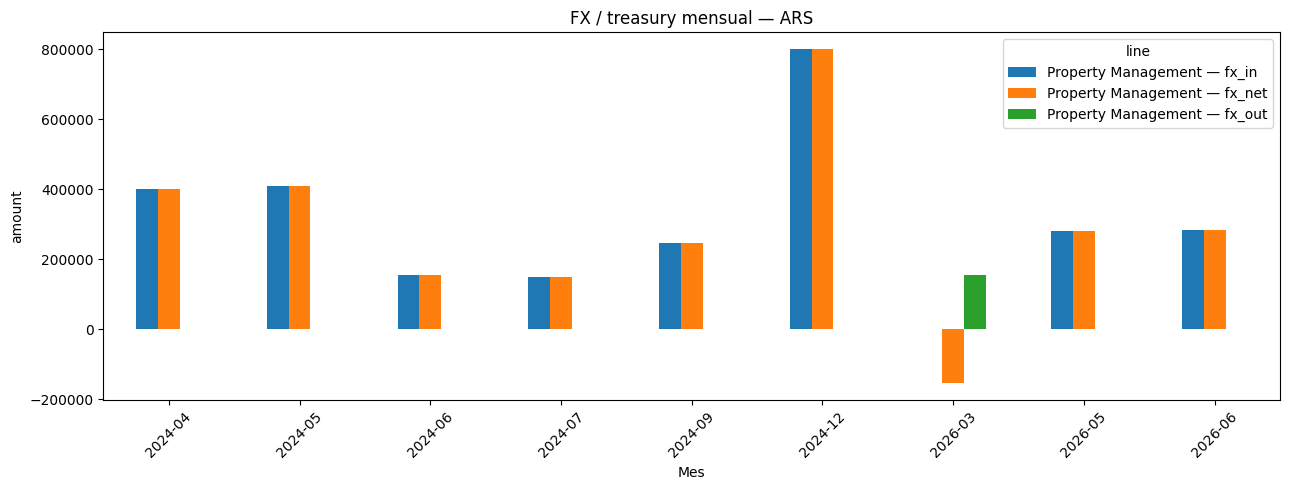

In [12]:
if not flow.empty:
    fx_mask = (
        flow["semantic_bucket"].str.contains("treasury_fx|fx", case=False, regex=True, na=False)
        | flow["semantic_subbucket"].str.contains("fx", case=False, regex=True, na=False)
        | flow["cash_path"].str.contains("FX|Cambio", case=False, regex=True, na=False)
        | flow["payer"].str.contains("^FX$", case=False, regex=True, na=False)
        | flow["receiver"].str.contains("^FX$", case=False, regex=True, na=False)
        | flow["counterparty"].str.contains("^FX$", case=False, regex=True, na=False)
    )
    fx = flow[fx_mask].copy()
    fx_month = fx.groupby(["period","Currency","Box","semantic_bucket","semantic_subbucket","cash_path"], dropna=False).agg(amount_in=("amount_in","sum"), amount_out=("amount_out","sum"), net_amount=("net_amount","sum"), amount_abs=("amount_abs","sum"), n_rows=("net_amount","size")).reset_index()
    display(fx_month)
    export_table(fx_month, repo_root, "monthly_dynamics_fx_audit.csv")
    fx_ars = fx[fx["Currency"].eq("ARS")].copy()
    fx_lines = fx_ars.groupby(["period","Box"], dropna=False).agg(fx_in=("amount_in","sum"), fx_out=("amount_out","sum"), fx_net=("net_amount","sum")).reset_index()
    fx_plot = fx_lines.melt(id_vars=["period","Box"], value_vars=["fx_in","fx_out","fx_net"], var_name="line", value_name="amount")
    fx_plot["line"] = fx_plot["Box"] + " — " + fx_plot["line"]
    plot_group(fx_plot, "line", "amount", "FX / treasury mensual — ARS", "08_fx_treasury_monthly_ars.png", max_groups=10)


## 11. Unknown / review-required

In [13]:
if not flow.empty:
    b = flow["semantic_bucket"].str.lower()
    sub = flow["semantic_subbucket"].str.lower()
    unk = flow[flow["Currency"].eq("ARS") & (b.str.contains("unknown|review", na=False) | sub.str.contains("unknown|review", na=False))].copy()
    unk_month = unk.groupby(["period","Box","semantic_bucket","semantic_subbucket","cash_path"], dropna=False).agg(amount_in=("amount_in","sum"), amount_out=("amount_out","sum"), net_amount=("net_amount","sum"), amount_abs=("amount_abs","sum"), n_rows=("net_amount","size")).reset_index()
    display(unk_month)
    export_table(unk_month, repo_root, "monthly_dynamics_unknown_review_ars.csv")
    plot_group(unk_month, "Box", "net_amount", "Unknown / review-required neto mensual por Box — ARS", "09_unknown_review_monthly_ars.png", max_groups=8)


,period,Box,semantic_bucket,semantic_subbucket,cash_path,amount_in,amount_out,net_amount,amount_abs,n_rows


No data: Unknown / review-required neto mensual por Box — ARS


## 12. Debt levels and activity

,period,pair,open_total
0,2023-05,Alejandro → PM,2100.0
1,2023-05,PM → MI,1740.0
2,2023-05,PM → Primos,360.0
3,2023-06,Alejandro → PM,4188.0
4,2023-06,PM → MI,3291.0
5,2023-06,PM → Primos,897.0
6,2023-07,Alejandro → PM,11511.0
7,2023-07,PM → MI,9090.0
8,2023-07,PM → Primos,2421.0
9,2023-08,Alejandro → PM,11752.5


saved: out/professional_pack/latest/figures/monthly_dynamics/10_debt_open_by_pair_monthly_usd.png


<Figure size 1300x500 with 0 Axes>

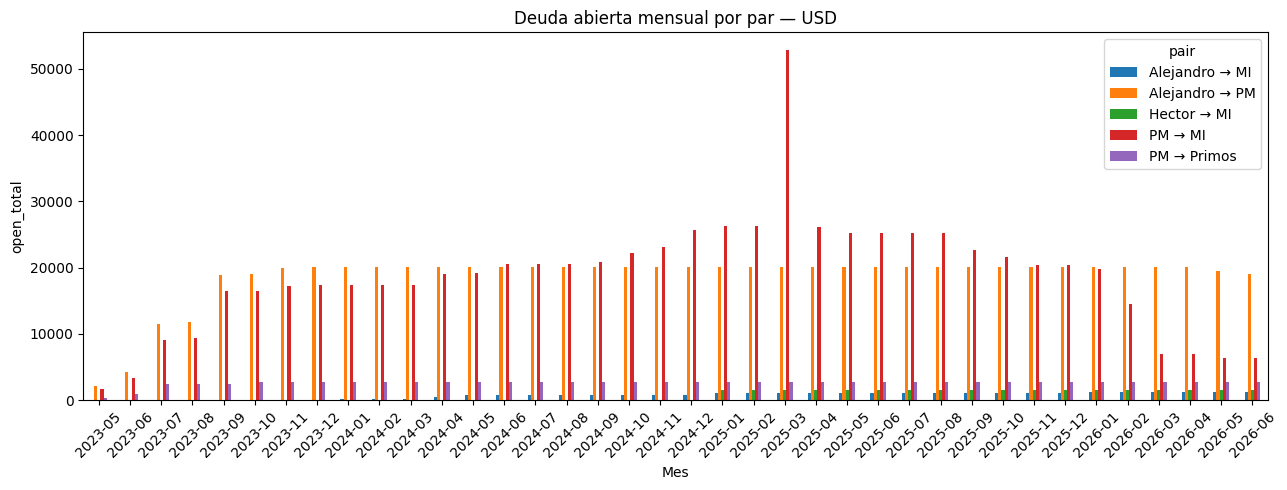

,period,new_principal,interest_accrued,repayments,adjustments,net_change
0,2023-05,1400.0,0.0,0.0,0.000000e+00,1400.0
1,2023-06,1392.0,0.0,0.0,0.000000e+00,1392.0
2,2023-07,4882.0,0.0,0.0,0.000000e+00,4882.0
3,2023-08,161.0,0.0,0.0,0.000000e+00,161.0
4,2023-09,4723.4,0.0,0.0,0.000000e+00,4723.4
5,2023-10,180.0,0.0,0.0,0.000000e+00,180.0
6,2023-11,556.0,0.0,207.0,1.930000e+02,542.0
7,2023-12,112.0,0.0,0.0,0.000000e+00,112.0
8,2024-01,19.0,174.0,0.0,-1.010000e+02,92.0
9,2024-02,0.0,0.0,0.0,0.000000e+00,0.0


saved: out/professional_pack/latest/figures/monthly_dynamics/11_debt_activity_monthly_usd.png


<Figure size 1300x500 with 0 Axes>

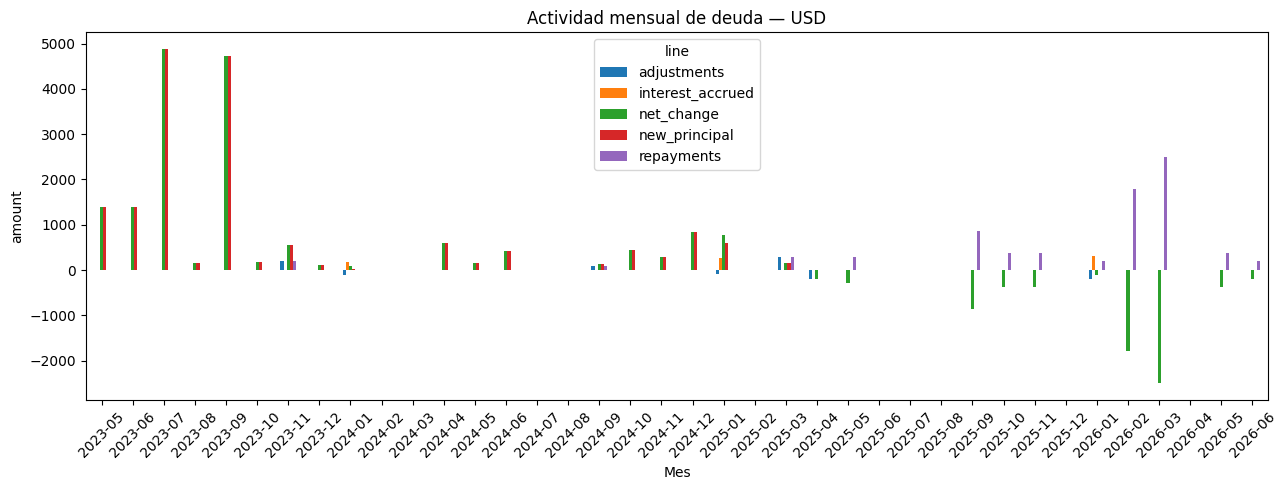

In [14]:
if not debt_pos.empty:
    dp = debt_pos[debt_pos["Currency"].eq("USD")].copy()
    dp_pair = dp.groupby(["period","pair"], dropna=False).agg(open_total=("open_total","sum")).reset_index()
    display(dp_pair.head(120))
    export_table(dp_pair, repo_root, "monthly_dynamics_debt_open_by_pair_usd.csv")
    plot_group(dp_pair, "pair", "open_total", "Deuda abierta mensual por par — USD", "10_debt_open_by_pair_monthly_usd.png", max_groups=8)

if not debt_act.empty:
    da = debt_act[debt_act["Currency"].eq("USD")].copy()
    da_tot = da.groupby("period", dropna=False).agg(new_principal=("new_principal","sum"), interest_accrued=("interest_accrued","sum"), repayments=("repayments","sum"), adjustments=("adjustments","sum"), net_change=("net_change","sum")).reset_index()
    display(da_tot)
    export_table(da_tot, repo_root, "monthly_dynamics_debt_activity_total_usd.csv")
    plot_group(melt_for_plot(da_tot, ["period"], ["new_principal","interest_accrued","repayments","adjustments","net_change"]), "line", "amount", "Actividad mensual de deuda — USD", "11_debt_activity_monthly_usd.png", max_groups=8)


## 13. Cash close and diagnostic levels

,period,Currency,Box,close_amount,is_frontend_safe,validation_status,cash_suitability,caveat,source_type
0,2022-01,ARS,Family Business,0.0,False,not_validated_for_frontend_cash,internal_only,Party-level daily cash position is an internal...,internal_party_balance
1,2022-01,ARS,Family Business,0.0,False,not_validated_for_frontend_cash,internal_only,Party-level daily cash position is an internal...,internal_party_balance
2,2022-01,ARS,Family Business,0.0,False,not_validated_for_frontend_cash,internal_only,Party-level daily cash position is an internal...,internal_party_balance
3,2022-01,ARS,Family Business,144000.0,False,not_validated_for_frontend_cash,internal_only,Party-level daily cash position is an internal...,internal_party_balance
4,2022-01,ARS,Family Business,0.0,False,not_validated_for_frontend_cash,internal_only,Party-level daily cash position is an internal...,internal_party_balance
5,2022-01,ARS,Family Business,0.0,False,not_validated_for_frontend_cash,internal_only,Party-level daily cash position is an internal...,internal_party_balance
6,2022-01,ARS,Family Business,-144000.0,False,not_validated_for_frontend_cash,internal_only,Party-level daily cash position is an internal...,internal_party_balance
7,2022-01,ARS,Family Business,0.0,False,not_validated_for_frontend_cash,internal_only,Party-level daily cash position is an internal...,internal_party_balance
8,2022-01,ARS,Family Business,0.0,False,not_validated_for_frontend_cash,internal_only,Party-level daily cash position is an internal...,internal_party_balance
9,2022-01,ARS,Family Business,0.0,False,not_validated_for_frontend_cash,internal_only,Party-level daily cash position is an internal...,internal_party_balance


saved: out/professional_pack/latest/figures/monthly_dynamics/12_cash_close_levels_monthly_ars.png


<Figure size 1300x500 with 0 Axes>

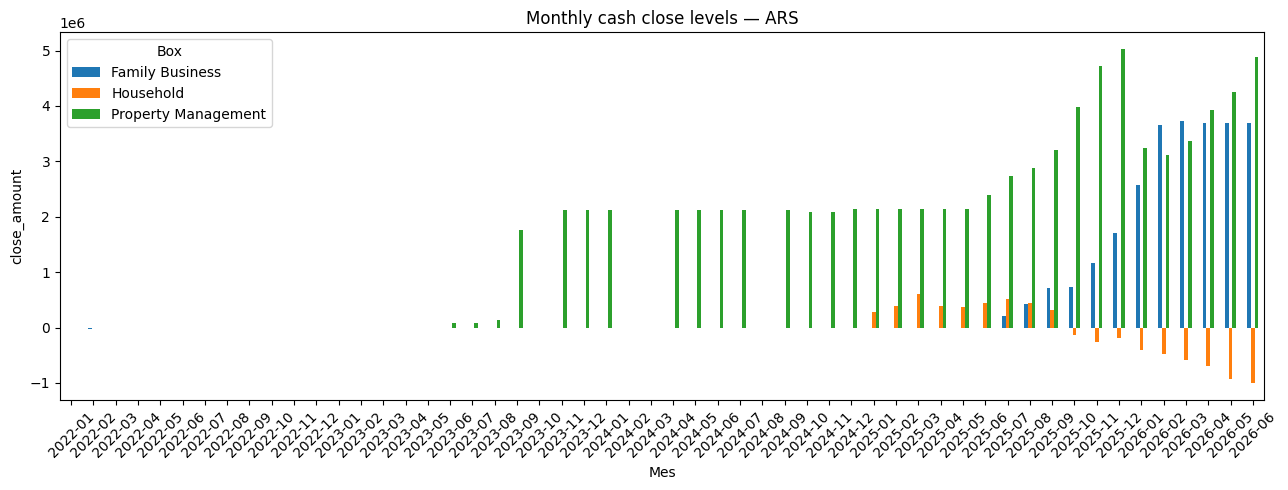

,period,Currency,Box,value
0,2022-01,ARS,Family Business,0.00
1,2022-02,ARS,Family Business,-17800.00
2,2022-03,ARS,Family Business,17800.00
3,2022-04,ARS,Family Business,0.00
4,2022-05,ARS,Family Business,0.00
5,2022-06,ARS,Family Business,0.00
6,2022-07,ARS,Family Business,0.00
7,2022-08,ARS,Family Business,0.00
8,2022-09,ARS,Family Business,0.00
9,2022-10,ARS,Family Business,0.00


saved: out/professional_pack/latest/figures/monthly_dynamics/13_diagnostic_box_levels_monthly_ars.png


<Figure size 1300x500 with 0 Axes>

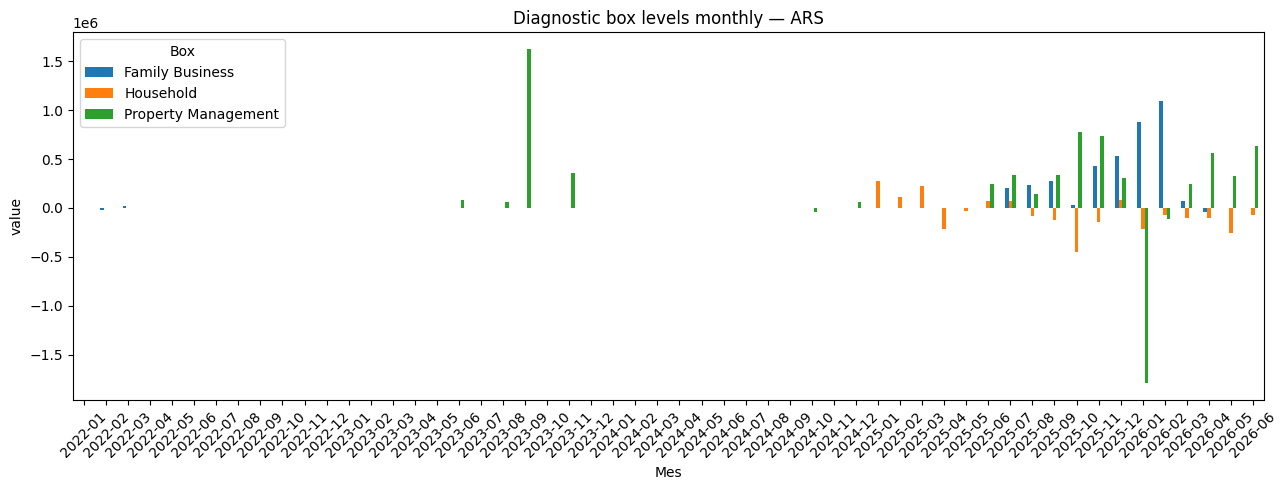

In [15]:
if not cash.empty:
    cash_ars = cash[cash["Currency"].eq("ARS")].copy()
    display(cash_ars.head(120))
    export_table(cash_ars, repo_root, "monthly_dynamics_cash_close_ars.csv")
    plot_group(cash_ars, "Box", "close_amount", "Monthly cash close levels — ARS", "12_cash_close_levels_monthly_ars.png", max_groups=8)

diag_raw = raw.get("box_balance_m_diagnostic", pd.DataFrame())
if not diag_raw.empty:
    p = col(diag_raw, ["TimePeriod","period","month","Date","TimePeriod_ts_end"])
    cur = col(diag_raw, ["Currency","currency"])
    boxc = col(diag_raw, ["Box","box","party","BoxParty"])
    val = col(diag_raw, ["balance","value","amount","net","cum_net"])
    if p and val:
        diag = pd.DataFrame({
            "period": monthify(diag_raw[p]),
            "Currency": diag_raw[cur].astype(str).str.strip() if cur else "N/A",
            "Box": diag_raw[boxc].astype(str).str.strip() if boxc else "N/A",
            "value": pd.to_numeric(diag_raw[val], errors="coerce").fillna(0.0),
        })
        diag_ars = diag[diag["Currency"].eq("ARS")].copy()
        display(diag_ars.head(120))
        export_table(diag_ars, repo_root, "monthly_dynamics_diagnostic_box_levels_ars.csv")
        plot_group(diag_ars, "Box", "value", "Diagnostic box levels monthly — ARS", "13_diagnostic_box_levels_monthly_ars.png", max_groups=8)


## 14. Export report / chart index

In [16]:
chart_index = pd.DataFrame([{"figure": p.name, "path": str(p.relative_to(repo_root))} for p in sorted(fig_dir.glob("*.png"))])
display(chart_index)
export_table(chart_index, repo_root, "monthly_dynamics_chart_index.csv")

comments = pd.DataFrame([
    {"tema": "Operación", "comentario": "Mirar renta, OPEX y net operating por mes para detectar compresión o shocks."},
    {"tema": "FB", "comentario": "Renta vs retiros muestra si el patrón de drenaje es mensual y mecánico."},
    {"tema": "PM", "comentario": "PM stress combina OPEX, funding, unknown, FX, deuda y net flow."},
    {"tema": "HH", "comentario": "Household se interpreta como scope real separado del long ledger."},
    {"tema": "FX", "comentario": "FX debe moverse a treasury semantics; hasta PR9 esta notebook lo audita por cash_path/payer/receiver."},
    {"tema": "Caja", "comentario": "Cash close requiere frontend-safe/validated; diagnostic box levels no son caja legal/auditada."},
])
display(comments)
export_table(comments, repo_root, "monthly_dynamics_professional_comments.csv")

md_path = write_markdown_report(repo_root, "06_monthly_dynamics_bar_charts.md", "06 — Monthly dynamics bar charts", [
    ("Scope", "Notebook de barras mensuales basada en artifacts mensuales existentes. No recalcula core accounting."),
    ("Monthly sources inventory", monthly_inventory),
    ("Chart index", chart_index),
    ("Professional comments", comments),
])
html_path = write_html_report(repo_root, "06_monthly_dynamics_bar_charts.html", "06 — Monthly dynamics bar charts", [
    ("Scope", "Notebook de barras mensuales basada en artifacts mensuales existentes. No recalcula core accounting."),
    ("Monthly sources inventory", monthly_inventory),
    ("Chart index", chart_index),
    ("Professional comments", comments),
])
print("markdown:", md_path.relative_to(repo_root))
print("html:", html_path.relative_to(repo_root))


,figure,path
0,01_operating_monthly_ars.png,out/professional_pack/latest/figures/monthly_d...
1,02_semantic_bucket_net_monthly_ars.png,out/professional_pack/latest/figures/monthly_d...
2,03_draws_by_box_monthly_ars.png,out/professional_pack/latest/figures/monthly_d...
3,04_fb_rent_vs_withdrawals_monthly_ars.png,out/professional_pack/latest/figures/monthly_d...
4,05_pm_stress_bridge_monthly_ars.png,out/professional_pack/latest/figures/monthly_d...
5,06_household_bridge_monthly_ars.png,out/professional_pack/latest/figures/monthly_d...
6,07_opex_by_category_monthly_ars.png,out/professional_pack/latest/figures/monthly_d...
7,08_fx_treasury_monthly_ars.png,out/professional_pack/latest/figures/monthly_d...
8,09_unknown_review_monthly_ars.png,out/professional_pack/latest/figures/monthly_d...
9,10_debt_open_by_pair_monthly_usd.png,out/professional_pack/latest/figures/monthly_d...


,tema,comentario
0,Operación,"Mirar renta, OPEX y net operating por mes para..."
1,FB,Renta vs retiros muestra si el patrón de drena...
2,PM,"PM stress combina OPEX, funding, unknown, FX, ..."
3,HH,Household se interpreta como scope real separa...
4,FX,FX debe moverse a treasury semantics; hasta PR...
5,Caja,Cash close requiere frontend-safe/validated; d...


markdown: out/professional_pack/latest/markdown/06_monthly_dynamics_bar_charts.md
html: out/professional_pack/latest/html/06_monthly_dynamics_bar_charts.html
